## Data Preparation

The pipeline begins by loading raw NCAA women’s basketball datasets, including regular season results, tournament results, and tournament seeds. Because the datasets cover different time periods, the analysis is restricted to seasons where all datasets overlap to ensure complete data and avoid missing values.

The raw data is transformed into a relational structure consisting of four tables: teams, seasons, regular_season_team_stats, and tournament_games. This structure separates team identity, season information, performance metrics, and tournament outcomes, allowing for clean joins and efficient querying.

## Data Preparation

The pipeline begins by loading raw NCAA women’s basketball datasets, including regular season results, tournament results, and tournament seeds.

Because these datasets cover different time periods, the analysis is restricted to seasons where all datasets overlap. This ensures complete data coverage and avoids systematic missing values.

The raw data is transformed into a relational structure consisting of four tables:
- teams
- seasons
- regular_season_team_stats
- tournament_games

This structure separates team identity, season information, performance metrics, and tournament outcomes.

In [7]:
import pandas as pd
import numpy as np
import duckdb
import logging
import sys

# Configure logging so the pipeline writes messages both to a log file
# and to the notebook output while it runs.
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[
        logging.FileHandler("project1_pipeline.log", mode="w"),
        logging.StreamHandler(sys.stdout)
    ]
)

# Create a logger object for recording pipeline progress and errors.
logger = logging.getLogger(__name__)

# Function: check_required_columns
# Purpose: verify that a dataframe contains all columns needed for the pipeline.
# If any required columns are missing, the function raises an error so the
# pipeline stops early with a clear message.
def check_required_columns(df, required_cols, name):
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"{name} missing columns: {missing}")

try:
    logger.info("Starting pipeline")

    # Load the raw CSV files into pandas DataFrames.
    # These files contain regular season results, tournament results,
    # tournament seeds, and team names.
    reg = pd.read_csv("WRegularSeasonDetailedResults.csv")
    tourney = pd.read_csv("WNCAATourneyCompactResults.csv")
    seeds = pd.read_csv("WNCAATourneySeeds.csv")
    teams_raw = pd.read_csv("WTeams.csv")

    # Validate that each raw dataset contains the columns required
    # to build the relational tables and features.
    check_required_columns(reg, ["Season", "WTeamID", "LTeamID", "WScore", "LScore"], "reg")
    check_required_columns(tourney, ["Season", "WTeamID", "LTeamID"], "tourney")
    check_required_columns(seeds, ["Season", "TeamID", "Seed"], "seeds")

    # Restrict the analysis to seasons that appear in all three main datasets.
    # This prevents missing values caused by joining years that are not shared.
    common_seasons = sorted(
        set(reg["Season"]).intersection(tourney["Season"]).intersection(seeds["Season"])
    )
    reg = reg[reg["Season"].isin(common_seasons)]
    tourney = tourney[tourney["Season"].isin(common_seasons)]
    seeds = seeds[seeds["Season"].isin(common_seasons)]

    # Create the teams table by keeping only team identifiers and names,
    # then removing duplicates so there is one row per team.
    teams = teams_raw[["TeamID", "TeamName"]].drop_duplicates()

    # Create the seasons table with one row per season used in the project.
    seasons = pd.DataFrame({"Season": common_seasons})

    # Build the "wins" summary table.
    # For each team-season, count how many games the team won and calculate
    # the average score in those wins.
    wins = reg.groupby(["Season", "WTeamID"]).agg(
        Wins=("WTeamID", "size"),
        AvgScore_W=("WScore", "mean")
    ).reset_index().rename(columns={"WTeamID": "TeamID"})

    # Build the "losses" summary table.
    # For each team-season, count how many games the team lost and calculate
    # the average score in those losses.
    losses = reg.groupby(["Season", "LTeamID"]).agg(
        Losses=("LTeamID", "size"),
        AvgScore_L=("LScore", "mean")
    ).reset_index().rename(columns={"LTeamID": "TeamID"})

    # Merge the wins and losses summaries together so each row represents
    # one team in one season.
    stats = pd.merge(wins, losses, on=["Season", "TeamID"], how="outer")

    # Replace missing values with 0 so teams with only wins or only losses
    # still have complete records.
    stats = stats.fillna(0)

    # Compute the total number of games played by adding wins and losses.
    stats["GamesPlayed"] = stats["Wins"] + stats["Losses"]

    # Compute win percentage as wins divided by games played.
    stats["WinPct"] = stats["Wins"] / stats["GamesPlayed"]

    # Compute average score across all games using a weighted average of
    # score in wins and score in losses.
    stats["AvgScore"] = (
        stats["AvgScore_W"] * stats["Wins"] +
        stats["AvgScore_L"] * stats["Losses"]
    ) / stats["GamesPlayed"]

    # Fill any remaining missing values that may occur after calculations.
    stats = stats.fillna(0)

    # Keep only the columns needed for the regular season team stats table.
    stats = stats[["Season", "TeamID", "AvgScore", "GamesPlayed", "Wins", "Losses", "WinPct"]]

    # Convert tournament seed values from text such as "W01" into numeric seeds.
    seeds["SeedNum"] = seeds["Seed"].str.extract(r"(\d+)").astype(int)

    # Rename winner and loser IDs in the tournament dataset to make the next
    # transformation steps easier to understand.
    t = tourney.rename(columns={"WTeamID": "WinnerID", "LTeamID": "LoserID"})

    # Randomly assign teams to Team1 and Team2 so Team1 is not always the winner.
    # This prevents the target variable from being biased by table construction.
    np.random.seed(42)
    mask = np.random.rand(len(t)) < 0.5

    t["Team1ID"] = np.where(mask, t["WinnerID"], t["LoserID"])
    t["Team2ID"] = np.where(mask, t["LoserID"], t["WinnerID"])

    # Create the binary outcome variable:
    # 1 if Team1 won the game, 0 otherwise.
    t["Team1Win"] = (t["Team1ID"] == t["WinnerID"]).astype(int)

    # Merge numeric seed values onto Team1 using season and team ID.
    t = t.merge(
        seeds[["Season", "TeamID", "SeedNum"]].rename(
            columns={"TeamID": "Team1ID", "SeedNum": "Team1Seed"}
        ),
        on=["Season", "Team1ID"],
        how="left"
    )

    # Merge numeric seed values onto Team2 using season and team ID.
    t = t.merge(
        seeds[["Season", "TeamID", "SeedNum"]].rename(
            columns={"TeamID": "Team2ID", "SeedNum": "Team2Seed"}
        ),
        on=["Season", "Team2ID"],
        how="left"
    )

    # Create a unique game identifier for each tournament matchup.
    t["GameID"] = range(1, len(t) + 1)

    # Keep only the columns needed for the tournament games table.
    tournament_games = t[["GameID", "Season", "Team1ID", "Team2ID", "Team1Seed", "Team2Seed", "Team1Win"]]

    # Save each relational table as its own CSV file for use in the repository
    # and later loading into DuckDB.
    teams.to_csv("teams.csv", index=False)
    seasons.to_csv("seasons.csv", index=False)
    stats.to_csv("regular_season_team_stats.csv", index=False)
    tournament_games.to_csv("tournament_games.csv", index=False)

    logger.info("Relational tables created")

# Catch any unexpected errors and write them to the log file.
except Exception as e:
    logger.exception("Pipeline failed")

## Query to Create Modeling Dataset

The final modeling dataset is created by joining the tournament_games table with the regular_season_team_stats table twice: once for Team 1 and once for Team 2.

This produces a matchup-level dataset where each row represents a tournament game. Additional features such as score differential, win percentage differential, and seed differential are computed to compare the two teams.

## Loading Data into DuckDB

The relational tables are loaded into DuckDB to enable SQL-based querying. This allows the pipeline to demonstrate relational database operations as required.

In [8]:
# Connect to a local DuckDB database file.
# If the file does not already exist, DuckDB will create it.
con = duckdb.connect("ncaa_project.duckdb")

# Load each CSV file into DuckDB as a relational table.
# "CREATE OR REPLACE TABLE" ensures the table is refreshed each time
# the pipeline is run.
con.execute("CREATE OR REPLACE TABLE teams AS SELECT * FROM read_csv_auto('teams.csv')")
con.execute("CREATE OR REPLACE TABLE seasons AS SELECT * FROM read_csv_auto('seasons.csv')")
con.execute("CREATE OR REPLACE TABLE regular_season_team_stats AS SELECT * FROM read_csv_auto('regular_season_team_stats.csv')")
con.execute("CREATE OR REPLACE TABLE tournament_games AS SELECT * FROM read_csv_auto('tournament_games.csv')")

# Run a SQL query to create the final modeling dataset.
# This query joins the tournament games table with the regular season
# statistics table twice:
#   - once to attach Team 1 statistics
#   - once to attach Team 2 statistics
#
# It also creates engineered features used for prediction:
#   - ScoreDiff: Team 1 average score minus Team 2 average score
#   - WinPctDiff: Team 1 win percentage minus Team 2 win percentage
#   - SeedDiff: Team 2 seed minus Team 1 seed
#
# The result is converted back into a pandas DataFrame so it can be
# used in later modeling steps.
final_model_df = con.execute("""
SELECT
    tg.GameID,
    tg.Season,
    tg.Team1ID,
    tg.Team2ID,
    tg.Team1Seed,
    tg.Team2Seed,
    rs1.AvgScore AS Team1AvgScore,
    rs2.AvgScore AS Team2AvgScore,
    rs1.WinPct AS Team1WinPct,
    rs2.WinPct AS Team2WinPct,
    rs1.AvgScore - rs2.AvgScore AS ScoreDiff,
    rs1.WinPct - rs2.WinPct AS WinPctDiff,
    tg.Team2Seed - tg.Team1Seed AS SeedDiff,
    tg.Team1Win
FROM tournament_games tg
LEFT JOIN regular_season_team_stats rs1
    ON tg.Season = rs1.Season AND tg.Team1ID = rs1.TeamID
LEFT JOIN regular_season_team_stats rs2
    ON tg.Season = rs2.Season AND tg.Team2ID = rs2.TeamID
""").df()

# Check for missing values in the final modeling dataset.
# This confirms that the joins worked correctly and that the dataset
# is complete before modeling.
print(final_model_df.isnull().sum())

GameID           0
Season           0
Team1ID          0
Team2ID          0
Team1Seed        0
Team2Seed        0
Team1AvgScore    0
Team2AvgScore    0
Team1WinPct      0
Team2WinPct      0
ScoreDiff        0
WinPctDiff       0
SeedDiff         0
Team1Win         0
dtype: int64


## Model Implementation

To predict NCAA tournament game outcomes, I implemented two models: logistic regression and random forest.

Logistic regression was chosen because it is interpretable and allows for understanding how each feature contributes to win probability. Random forest was included as a more flexible model capable of capturing nonlinear relationships.

Comparing these models allows for evaluating whether a simple or more complex approach performs better for this prediction task.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score
import numpy as np

# Set a global random seed to ensure reproducibility across runs.
np.random.seed(42)

# Define feature matrix (X) and target variable (y).
# Features represent differences between teams in performance metrics.
X = final_model_df[["ScoreDiff", "WinPctDiff", "SeedDiff"]]
y = final_model_df["Team1Win"]

# Split the dataset into training and testing sets.
# 80% of the data is used for training and 20% for testing.
# random_state ensures the same split is used each time.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Logistic Regression Model
# -----------------------------
# Logistic regression is used as a baseline model because it is simple
# and provides interpretable relationships between features and outcomes.
log = LogisticRegression(max_iter=1000)

# Train the model on the training data.
log.fit(X_train, y_train)

# Predict probabilities on the test set and compute AUC.
# AUC measures how well the model distinguishes between wins and losses.
log_auc = roc_auc_score(y_test, log.predict_proba(X_test)[:, 1])

# -----------------------------
# Random Forest Model
# -----------------------------
# Random forest is a more flexible model that can capture nonlinear
# relationships between features and outcomes.
rf = RandomForestClassifier(random_state=42)

# Train the random forest model.
rf.fit(X_train, y_train)

# Compute AUC for the random forest model.
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

# Print model performance results.
print("Logistic AUC:", log_auc)
print("Random Forest AUC:", rf_auc)

Logistic AUC: 0.8276159654800431
Random Forest AUC: 0.806957928802589


## Analysis Rationale

The model uses score differential, win percentage differential, and seed differential because these variables capture team performance and tournament expectations in a simple and interpretable way.

A train-test split is used to evaluate model performance on unseen data. AUC is chosen as the primary metric because it measures how well the model distinguishes between wins and losses across all thresholds, making it more appropriate than accuracy for this classification problem.

## Results Interpretation

The logistic regression model achieved an AUC of 0.828, outperforming the random forest model, which achieved an AUC of 0.807.

This suggests that a simple linear model is sufficient to capture the relationship between team performance and tournament outcomes. The results indicate that the selected features like score differential, win percentage differential, and seed differential, are strong predictors of success and do not require complex nonlinear modeling.

## Visualization

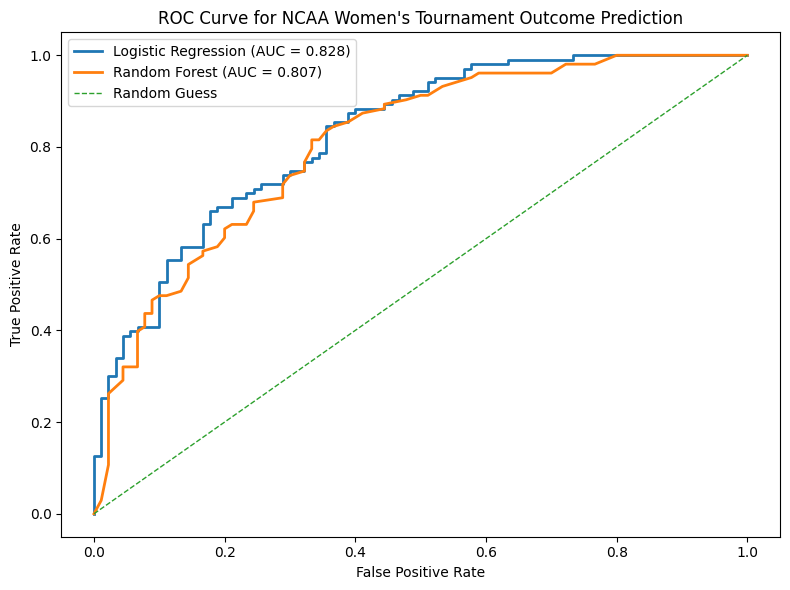

In [10]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Compute ROC curve values for each model.
# The ROC curve shows the relationship between:
#   - True Positive Rate (TPR)
#   - False Positive Rate (FPR)
# across different classification thresholds.
log_fpr, log_tpr, _ = roc_curve(y_test, log.predict_proba(X_test)[:, 1])
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf.predict_proba(X_test)[:, 1])

# Create a figure for plotting the ROC curves.
plt.figure(figsize=(8, 6))

# Plot ROC curve for logistic regression.
# The label includes the AUC value to summarize model performance.
plt.plot(
    log_fpr,
    log_tpr,
    linewidth=2,
    label=f"Logistic Regression (AUC = {log_auc:.3f})"
)

# Plot ROC curve for random forest.
plt.plot(
    rf_fpr,
    rf_tpr,
    linewidth=2,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

# Plot the diagonal baseline representing random guessing.
# A model performing along this line has no predictive power.
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random Guess"
)

# Add title and axis labels for clarity.
plt.title("ROC Curve for NCAA Women's Tournament Outcome Prediction")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

# Add a legend to distinguish between models.
plt.legend()

# Adjust layout to prevent clipping of labels and titles.
plt.tight_layout()

# Save the figure as a high-resolution image for use in the report or press release.
plt.savefig("roc_curve_comparison.png", dpi=300, bbox_inches="tight")

# Display the plot.
plt.show()

## Visualization Rationale

I used a Receiver Operating Characteristic (ROC) curve to evaluate and compare model performance because it provides a comprehensive view of how well each model distinguishes between wins and losses across all possible classification thresholds. Unlike a single metric such as accuracy, the ROC curve captures the tradeoff between true positive rate and false positive rate, making it more appropriate for assessing binary classification models.

The ROC curve also allows for direct visual comparison between logistic regression and random forest, showing which model performs better across different decision boundaries. Including the diagonal “random guess” line provides a clear baseline for comparison, making it easy to interpret model effectiveness.
This visualization provides both a performance comparison and an interpretable understanding of the model, making it well-suited for communicating results in a clear and meaningful way.